# Continuous-Time Koopman Dynamics for Irregularly-Sampled Graphs

This notebook assumes the encode → Koopman step → decode workflow from [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb), then extends that loop to continuous-time generators with irregular $\Delta t$.

**Synthetic identifiability tutorial.** This notebook demonstrates continuous-time Koopman
integration on a *known* linear system with irregular sampling intervals. It is **not** an
end-to-end METR-LA traffic forecasting walkthrough — that workflow lives in
[`03_traffic_network.ipynb`](03_traffic_network.ipynb) (temporal splits, per-horizon metrics,
DMD baseline).

## What this notebook demonstrates

1. **Generator learning.** Fit `ContinuousKoopmanOperator` to irregularly timed pairs and
   recover the true generator spectrum $L^\star$ (§3).
2. **Δt-awareness.** Continuous one-step error stays flat across sampling gaps; a fixed-step
   discrete operator fails under variable $\Delta t$ (§4).
3. **API contract.** `GraphKoopmanModel(dynamics_mode="continuous").predict_at(query_times=...)`
   forecasts at arbitrary horizons; discrete mode rejects off-grid queries (§5).
   Absolute horizons use `query_times=`; incremental intervals use `step_deltas=` (same method).

## Motivation: why continuous time?

Graph telemetry (traffic, power, sensor networks) is often **irregularly sampled**:
inter-reading intervals vary. A discrete Koopman step $z_{t+1} = z_t K^\top$
bakes in a *fixed* $\Delta t$ and cannot represent a variable one.
Continuous-time KoopmanGraph instead learns a **generator** $L$ and integrates
with a matrix exponential (standard continuous-time Koopman / matrix semigroup):

$$K(\Delta t) = \exp(L \cdot \Delta t).$$

The library advances row latents as $z_{t+\Delta t} = z_t\, K(\Delta t)^\top$
(equivalently $\dot z = z L^\top$). §§1–4 below use **column-vector**
1D states $z(t)=\exp(L t)\,z_0$ for clarity; for length-$d$ vectors the two
layouts are numerically equivalent. To verify the mechanism in isolation, we
use a synthetic system with a *known* $L^\star$ rather than real traffic caches
(see **Next steps** at the end).

## Why not METR-LA here?

Two confounds block a fair real-data demo in this notebook:

1. **Forecastability.** On short, per-sensor z-scored METR-LA windows the step residual is
   near white noise — the MSE-optimal forecast is a flat mean line, so no operator can
   (or should) trace the fluctuations. That is a property of the data, not of continuous vs.
   discrete integration.
2. **GNN autoencoder error.** Encoder/decoder reconstruction is common-mode to both models and
   can dominate, masking the Δt effect we want to isolate.

So we build the column ODE $\dot z = L^\star z$, sample it at irregular times, and fit
the library's operators directly. §5 then exercises the end-to-end
`GraphKoopmanModel.predict_at` API on a graph sequence built from the same synthetic
dynamics.


In [1]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

from koopman_graph import (
    ContinuousKoopmanOperator,
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
    KoopmanOperator,
)
from koopman_graph.training import LossWeights
from koopman_graph.analysis import compute_generator_spectrum

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")
    warnings.filterwarnings("ignore")

# --- notebook globals / hyperparameters ---
SEED = 0
BASE_DT = 0.25  # nominal step a fixed-rate sensor would assume
TRUE_LATENT_DIM = 4
Z0 = torch.tensor([1.0, 0.2, -0.5, 0.8])
OPERATOR_EPOCHS = 1500
OPERATOR_LR = 1e-2
OPERATOR_INIT_SCALE = 0.1

TRAIN_SAMPLES = 120
TRAIN_TIME_SEED = 1
TEST_SAMPLES = 160
TEST_TIME_SEED = 7
FORECAST_HORIZON = 30.0

NUM_NODES = 12
GRAPH_LATENT_DIM = 12
GRAPH_HIDDEN = 32
GRAPH_SAMPLES = 40
GRAPH_TIME_SEED = 2
GRAPH_SPLIT = 30
GRAPH_LR = 5e-3
GRAPH_EPOCHS = 12 if os.environ.get("PYTEST_CURRENT_TEST") else 40

torch.manual_seed(SEED)

def rotation_block(decay: float, freq: float) -> torch.Tensor:
    """2x2 generator block with eigenvalues decay ± i·freq."""
    return torch.tensor([[decay, -freq], [freq, decay]])

GENERATOR_TRUE = torch.zeros(TRUE_LATENT_DIM, TRUE_LATENT_DIM)
GENERATOR_TRUE[:2, :2] = rotation_block(-0.10, 1.4)
GENERATOR_TRUE[2:, 2:] = rotation_block(-0.30, 0.5)
EIGS_TRUE = torch.linalg.eigvals(GENERATOR_TRUE)

PHASE = torch.linspace(0, 2 * torch.pi, NUM_NODES + 1)[:-1]
_SRC = torch.arange(NUM_NODES)
_DST = (_SRC + 1) % NUM_NODES
EDGE_INDEX = torch.stack([torch.cat([_SRC, _DST]), torch.cat([_DST, _SRC])])
del _SRC, _DST


## Helper functions

Notebook-local helpers used below. They take explicit arguments (or only close over
globals defined in the setup cell).


In [2]:
def irregular_times(num: int, seed: int, base_dt: float = BASE_DT) -> torch.Tensor:
    gen = torch.Generator().manual_seed(seed)
    gaps = base_dt * (0.3 + 2.7 * torch.rand(num - 1, generator=gen))
    times = torch.zeros(num)
    times[1:] = gaps.cumsum(dim=0)
    return times


def trajectory(
    times: torch.Tensor,
    generator: torch.Tensor = GENERATOR_TRUE,
    z0: torch.Tensor = Z0,
) -> torch.Tensor:
    return torch.stack([torch.matrix_exp(generator * float(t)) @ z0 for t in times])


def sort_key(values):
    return sorted((round(v.real.item(), 3), round(v.imag.item(), 3)) for v in values)


def node_signal(t: float, phase: torch.Tensor = PHASE) -> torch.Tensor:
    wave = torch.exp(torch.tensor(-0.1 * t)) * torch.cos(1.2 * t + phase)
    return wave.unsqueeze(-1)


## 1. Generate a known continuous-time system

A synthetic linear generator with irregular sampling times — chosen so we can
check whether the continuous operator recovers the true spectrum.


In [3]:
train_times = irregular_times(TRAIN_SAMPLES, seed=TRAIN_TIME_SEED)
Z_train = trajectory(train_times)
train_gaps = train_times[1:] - train_times[:-1]

print(
    "true generator eigenvalues:",
    [complex(round(e.real.item(), 3), round(e.imag.item(), 3)) for e in EIGS_TRUE],
)
print(
    f"train samples: {Z_train.shape[0]}, Δt range: "
    f"{float(train_gaps.min()):.3f}–{float(train_gaps.max()):.3f} (nominal {BASE_DT})"
)


true generator eigenvalues: [(-0.1+1.4j), (-0.1-1.4j), (-0.3+0.5j), (-0.3-0.5j)]
train samples: 120, Δt range: 0.083–0.749 (nominal 0.25)


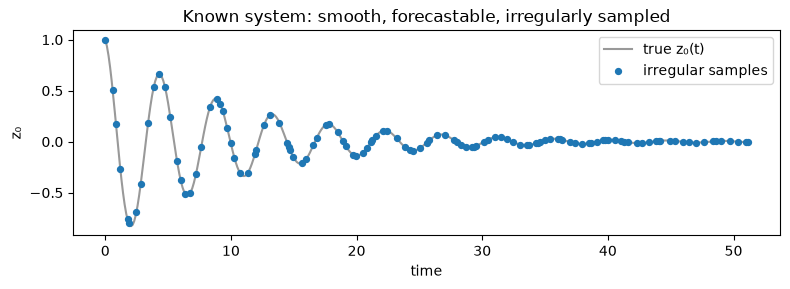

In [4]:
dense_times = torch.linspace(0.0, float(train_times[-1]), 400)
Z_dense = trajectory(dense_times)

plt.figure(figsize=(8, 3))
plt.plot(dense_times, Z_dense[:, 0], color="0.6", label="true z₀(t)")
plt.scatter(train_times, Z_train[:, 0], s=18, color="C0", zorder=3, label="irregular samples")
plt.xlabel("time")
plt.ylabel("z₀")
plt.title("Known system: smooth, forecastable, irregularly sampled")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Fit continuous vs discrete operators

Fit both operators to the *same* irregular pairs, then compare one-step behavior
across sampling gaps.


In [5]:
z_in, z_out = Z_train[:-1], Z_train[1:]

continuous_op = ContinuousKoopmanOperator(
    latent_dim=TRUE_LATENT_DIM,
    parameterization="dense",
    init_scale=OPERATOR_INIT_SCALE,
)
discrete_op = KoopmanOperator(latent_dim=TRUE_LATENT_DIM)

opt_c = torch.optim.Adam(continuous_op.parameters(), lr=OPERATOR_LR)
opt_d = torch.optim.Adam(discrete_op.parameters(), lr=OPERATOR_LR)

for _ in range(OPERATOR_EPOCHS):
    opt_c.zero_grad()
    # K(Δt_i) = exp(L·Δt_i) for every pair, then propagate (advance() is the per-sample wrapper).
    K_batch = torch.matrix_exp(continuous_op.L * train_gaps[:, None, None])
    pred_c = torch.bmm(K_batch, z_in.unsqueeze(-1)).squeeze(-1)
    loss_c = ((pred_c - z_out) ** 2).mean()
    loss_c.backward()
    opt_c.step()

    opt_d.zero_grad()
    loss_d = ((discrete_op(z_in) - z_out) ** 2).mean()
    loss_d.backward()
    opt_d.step()

print(
    f"final train MSE  —  continuous: {loss_c.detach().item():.2e}   "
    f"discrete (fixed K): {loss_d.detach().item():.2e}"
)


final train MSE  —  continuous: 5.48e-13   discrete (fixed K): 1.23e-03


## 3. Evaluate: continuous operator recovers the true generator

Spectral comparison against the known generator $L^\star$.


In [6]:
spectrum = compute_generator_spectrum(continuous_op.L.detach())

print("true    eigenvalues:", sort_key(EIGS_TRUE))
print("learned eigenvalues:", sort_key(spectrum.eigenvalues))
max_real_err = (torch.sort(spectrum.eigenvalues.real).values - torch.sort(EIGS_TRUE.real).values).abs().max()
max_imag_err = (torch.sort(spectrum.eigenvalues.imag).values - torch.sort(EIGS_TRUE.imag).values).abs().max()
assert float(max_real_err) < 1e-2, f"real-part recovery failed: {float(max_real_err)}"
assert float(max_imag_err) < 1e-2, f"imag-part recovery failed: {float(max_imag_err)}"
assert bool(torch.all(spectrum.growth_rates < 0)), "learned generator is not Hurwitz-stable"
print(
    f"max |d Re(lambda)| = {float(max_real_err):.2e}, "
    f"max |d Im(lambda)| = {float(max_imag_err):.2e} -- recovery OK, Hurwitz-stable"
)


true    eigenvalues: [(-0.3, -0.5), (-0.3, 0.5), (-0.1, -1.4), (-0.1, 1.4)]
learned eigenvalues: [(-0.3, -0.5), (-0.3, 0.5), (-0.1, -1.4), (-0.1, 1.4)]
max |d Re(lambda)| = 3.05e-07, max |d Im(lambda)| = 3.58e-07 -- recovery OK, Hurwitz-stable


## 4. Results: continuous tracks the trajectory at arbitrary times

Continuous one-step error stays flat across sampling gaps. A fixed-step discrete
operator cannot adapt its map to each gap, so its one-step error is larger under
irregular $\Delta t$ (not necessarily a smooth function of distance from the
nominal step).


In [7]:
test_times = irregular_times(TEST_SAMPLES, seed=TEST_TIME_SEED)
Z_test = trajectory(test_times)
test_gaps = test_times[1:] - test_times[:-1]

with torch.no_grad():
    err_cont, err_disc = [], []
    for i in range(len(Z_test) - 1):
        pred_c = continuous_op.advance(Z_test[i], float(test_gaps[i]))
        pred_d = discrete_op(Z_test[i])
        err_cont.append(float((pred_c - Z_test[i + 1]).abs().mean()))
        err_disc.append(float((pred_d - Z_test[i + 1]).abs().mean()))

mae_cont = sum(err_cont) / len(err_cont)
mae_disc = sum(err_disc) / len(err_disc)
print(f"held-out one-step MAE  --  continuous: {mae_cont:.4f}   discrete: {mae_disc:.4f}")
assert mae_cont < 1e-3, f"continuous one-step MAE too large: {mae_cont}"
assert mae_cont < mae_disc, "continuous should beat fixed-step discrete under irregular sampling"

# Full-trajectory forecast from z0.
with torch.no_grad():
    cont_forecast = torch.stack([continuous_op.advance(Z0, float(t)) for t in test_times])
    traj_err = float((cont_forecast - Z_test).abs().mean())
    assert traj_err < 1e-2, f"continuous multi-step trajectory error too large: {traj_err}"
    print(f"continuous multi-step trajectory MAE from z0: {traj_err:.2e}")
    n_uniform = int(test_times[-1] / BASE_DT) + 1
    uniform_times = BASE_DT * torch.arange(n_uniform)
    disc_forecast = [Z0]
    for _ in range(n_uniform - 1):
        disc_forecast.append(discrete_op(disc_forecast[-1]))
    disc_forecast = torch.stack(disc_forecast)


held-out one-step MAE  --  continuous: 0.0000   discrete: 0.0114
continuous multi-step trajectory MAE from z0: 2.77e-07


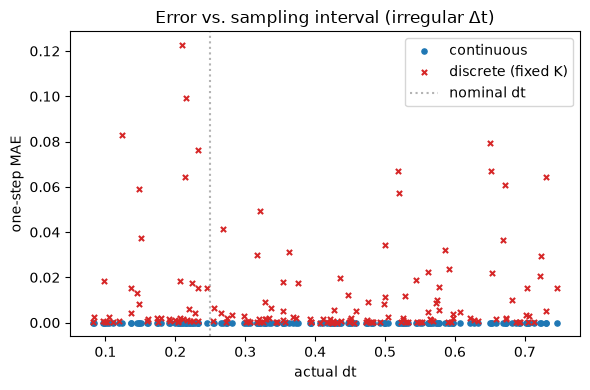

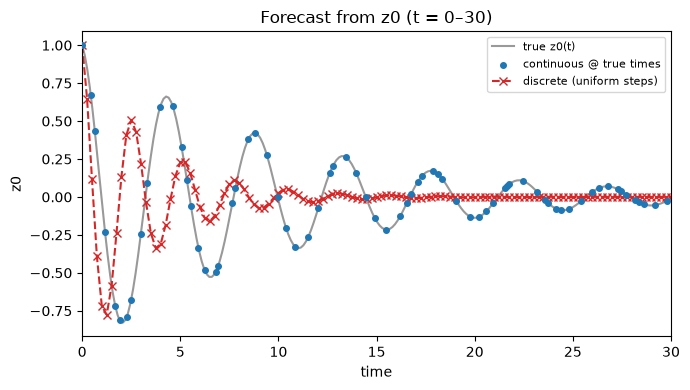

In [8]:
plot_horizon = float(max(test_times[-1], train_times[-1]))
dense_plot = torch.linspace(0.0, plot_horizon, 500)
Z_plot = trajectory(dense_plot)

plt.figure(figsize=(6, 4))
plt.scatter(test_gaps, err_cont, s=14, color="C0", label="continuous")
plt.scatter(test_gaps, err_disc, s=14, color="C3", marker="x", label="discrete (fixed K)")
plt.axvline(BASE_DT, color="0.7", linestyle=":", label="nominal dt")
plt.xlabel("actual dt")
plt.ylabel("one-step MAE")
plt.title("Error vs. sampling interval (irregular Δt)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(dense_plot, Z_plot[:, 0], color="0.6", label="true z0(t)")
plt.scatter(
    test_times,
    cont_forecast[:, 0],
    s=16,
    color="C0",
    zorder=3,
    label="continuous @ true times",
)
plt.plot(
    uniform_times,
    disc_forecast[:, 0],
    color="C3",
    marker="x",
    linestyle="--",
    label="discrete (uniform steps)",
)
plt.xlim(0, FORECAST_HORIZON)
plt.xlabel("time")
plt.ylabel("z0")
plt.title(f"Forecast from z0 (t = 0–{FORECAST_HORIZON:g})")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. End-to-end graph API: `GraphKoopmanModel.predict_at`

Continuous mode accepts absolute horizons via `query_times=` (or incremental
intervals via `step_deltas=`). Discrete mode rejects off-grid queries.

This section only exercises the API on a short synthetic graph sequence with a
**dense** continuous operator (soft spectral penalty at most). A positive
$\max\mathrm{Re}(\lambda)$ here is **not** a failed claim — use structural modes
(`schur` / `dissipative` / Lyapunov) or `examples/11_long_horizon_stability.ipynb`
when you need a Hurwitz certificate.


In [9]:
graph_times = irregular_times(GRAPH_SAMPLES, seed=GRAPH_TIME_SEED)
snapshots = [Data(x=node_signal(float(t)), edge_index=EDGE_INDEX) for t in graph_times]
sequence = GraphSnapshotSequence(snapshots, timestamps=graph_times)

train_seq = sequence.slice(0, GRAPH_SPLIT)
test_seq = sequence.slice(GRAPH_SPLIT, sequence.num_timesteps)
query_times = [
    float(test_seq.timestamps[i] - test_seq.timestamps[0])
    for i in range(1, test_seq.num_timesteps)
]

graph_model = GraphKoopmanModel(
    GNNEncoder(in_channels=1, hidden_channels=GRAPH_HIDDEN, latent_dim=GRAPH_LATENT_DIM),
    GNNDecoder(latent_dim=GRAPH_LATENT_DIM, hidden_channels=GRAPH_HIDDEN, out_channels=1),
    latent_dim=GRAPH_LATENT_DIM,
    time_step=BASE_DT,
    dynamics_mode="continuous",
    koopman_parameterization="dense",
)
graph_model.fit(
    train_seq,
    epochs=GRAPH_EPOCHS,
    lr=GRAPH_LR,
    loss_weights=LossWeights(reconstruction=1.0, forward=1.0),
)

forecasts = graph_model.predict_at(test_seq[0], query_times=query_times)
print(
    f"continuous predict_at accepted {len(query_times)} irregular query times "
    f"→ {len(forecasts)} snapshots"
)
gen_spectrum = graph_model.spectrum()
max_growth = float(gen_spectrum.growth_rates.detach().max())
print(
    f"dense generator max Re(λ) = {max_growth:.3f} "
    f"(informational only; dense mode is not a Hurwitz certificate)"
)


continuous predict_at accepted 9 irregular query times → 9 snapshots
dense generator max Re(λ) = 0.077 (informational only; dense mode is not a Hurwitz certificate)


In [10]:
discrete_model = GraphKoopmanModel(
    GNNEncoder(in_channels=1, hidden_channels=GRAPH_HIDDEN, latent_dim=GRAPH_LATENT_DIM),
    GNNDecoder(latent_dim=GRAPH_LATENT_DIM, hidden_channels=GRAPH_HIDDEN, out_channels=1),
    latent_dim=GRAPH_LATENT_DIM,
    time_step=BASE_DT,
    dynamics_mode="discrete",
)

try:
    discrete_model.predict_at(test_seq[0], query_times=query_times)
    raise AssertionError("expected discrete model to reject irregular query_times")
except ValueError as exc:
    print(f"discrete model correctly rejected irregular query_times:\n  {exc}")


discrete model correctly rejected irregular query_times:
  discrete dynamics_mode requires uniform increments equal to time_step=0.25; got 0.10591316223144531. Use dynamics_mode='continuous' for irregular sampling.


## Takeaways

- **Exact recovery.** From irregularly-timed samples of a known linear system, the
  continuous operator recovers $L^\star$'s spectrum to numerical precision (§3).
- **Δt-awareness is the mechanism.** Continuous one-step error is flat across sampling
  intervals; the fixed-step discrete operator fails under variable $\Delta t$ (§4).
- **API contract.** `GraphKoopmanModel(dynamics_mode="continuous").predict_at(query_times=...)`
  (or `step_deltas=...`) serves arbitrary horizons; the discrete model refuses off-grid
  queries (§5). Dense continuous fits are for the timing API — not a stability certificate.

## Next steps

- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for end-to-end METR-LA forecasting (temporal splits, DMD baseline).
- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the discrete encode → Koopman → decode workflow.
- See [`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb) for structural continuous/discrete stability modes.
- See [`20_continuous_spectrum_auxiliary_network.ipynb`](20_continuous_spectrum_auxiliary_network.ipynb) for continuous-spectrum auxiliaries.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
